# Linear Regression – Analysis
**AIPI 520 · Project 1 · Team 5**

In this notebook we explain how we built our linear regression model for the RDU hourly temperature (Sep 17–30 2026). Every choice is checked with data and with time series cross-validation. The final model is in `src/linear_regression_model.py`.

**Sections**
0. Data
1. EDA
2. Evaluation design
3. Baselines
4. Stage 1: climatology
5. Stage 2: anomaly
6. Collinearity and regularization
7. Interpretation
8. Residuals
9. Error by forecast day
10. Validation and test
11. Final forecast
12. Summary

It takes around 8 minutes to run, mostly because of the cross-validation.

In [1]:
import sys, warnings
from pathlib import Path
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Paths, so it works from the repo root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from linear_regression_model import *   # model, features, CV and metrics
warnings.filterwarnings("ignore")

# All the figures are saved here for the slides
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10, "axes.titleweight": "bold"})
COL = {"actual": "#222222", "naive": "#9e9e9e", "monthhour": "#7f7f7f", "shared": "#a6cee3",
       "clim": "#1f78b4", "final": "#e6550d", "prophet": "#6a3d9a", "band": "#fdae6b"}

def save(fig, name):
    fig.savefig(FIG_DIR / f"lr_{name}.png", dpi=160, bbox_inches="tight")

## 0. Data
We load the shared splits from `data_pipeline.py` (UTC, one temperature per hour, missing hours as NaN).

In [2]:
train, val, test = load_split("train"), load_split("val"), load_split("test")
history = load_history()               # every hour before Sep 17 00:00 EDT
summary = pd.DataFrame([{"split": n, "start": d.ds.min(), "end": d.ds.max(), "hours": len(d),
                         "missing_y": int(d.y.isna().sum())}
                        for n, d in [("train", train), ("val", val), ("test", test), ("history", history)]])
summary

,split,start,end,hours,missing_y
0,train,2015-01-01 00:00:00+00:00,2026-08-20 03:00:00+00:00,101980,157
1,val,2026-08-20 04:00:00+00:00,2026-09-03 03:00:00+00:00,336,0
2,test,2026-09-03 04:00:00+00:00,2026-09-17 03:00:00+00:00,336,0
3,history,2015-01-01 00:00:00+00:00,2026-09-17 03:00:00+00:00,102652,157


## 1. EDA
### 1.1 Daily cycle
The daily cycle is not a perfect sine wave, so we need more than one daily harmonic. The daily range and its timing also change with the season, so we add interaction terms between the daily and the annual cycle.

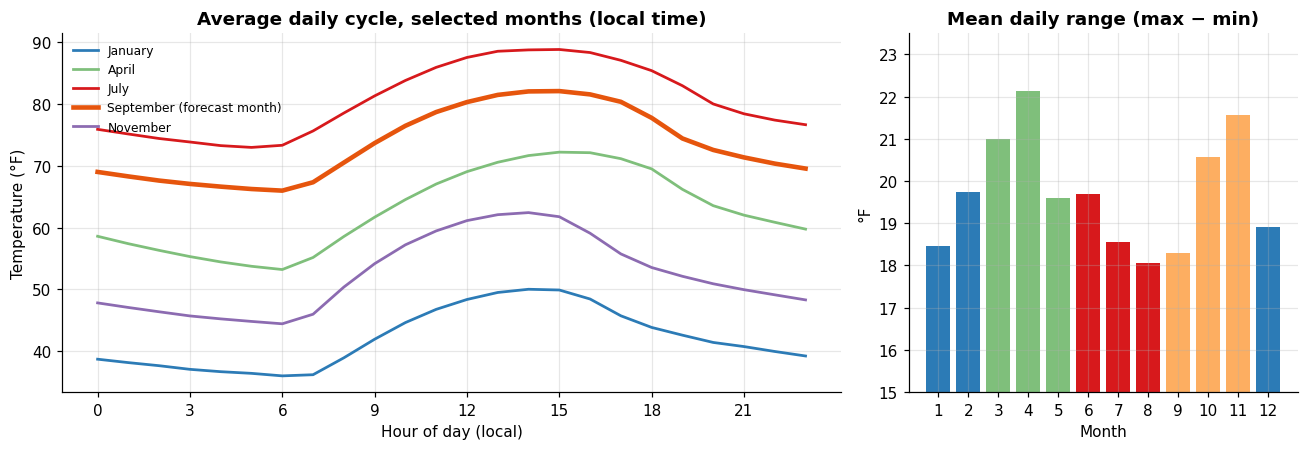

Daily range by month (°F): {1: 18.5, 2: 19.7, 3: 21.0, 4: 22.1, 5: 19.6, 6: 19.7, 7: 18.6, 8: 18.1, 9: 18.3, 10: 20.6, 11: 21.6, 12: 18.9}


In [3]:
# First we compute the average temperature for each month and local hour
obs = history.dropna().copy()
obs["local"] = obs.ds.dt.tz_convert(LOCAL_TZ)
cycle = obs.groupby([obs.local.dt.month, obs.local.dt.hour]).y.mean().unstack(0)
# Then the daily range (max - min) for every day
rng = obs.groupby(obs.local.dt.date).y.agg(lambda s: s.max() - s.min())
rng_by_month = rng.groupby(pd.to_datetime(pd.Series(rng.index)).dt.month.values).mean()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [2, 1]})
month_colors = {1: "#2c7bb6", 4: "#7fbf7b", 7: "#d7191c", 9: COL["final"], 11: "#8c6bb1"}
for m, c in month_colors.items():
    axes[0].plot(cycle.index, cycle[m], color=c, lw=3 if m == 9 else 1.8,
                 label=pd.Timestamp(2026, m, 1).strftime("%B") + (" (forecast month)" if m == 9 else ""))
axes[0].set(title="Average daily cycle, selected months (local time)", xlabel="Hour of day (local)", ylabel="Temperature (°F)",
            xticks=range(0, 24, 3))
axes[0].legend(fontsize=8, frameon=False, loc="upper left")
season = {12: "#2c7bb6", 1: "#2c7bb6", 2: "#2c7bb6", 3: "#7fbf7b", 4: "#7fbf7b", 5: "#7fbf7b",
          6: "#d7191c", 7: "#d7191c", 8: "#d7191c", 9: "#fdae61", 10: "#fdae61", 11: "#fdae61"}
axes[1].bar(rng_by_month.index, rng_by_month.values, color=[season[m] for m in rng_by_month.index])
axes[1].set(title="Mean daily range (max − min)", xlabel="Month", ylabel="°F", xticks=range(1, 13), ylim=(15, 23.5))
fig.tight_layout(); save(fig, "01_eda_daily_cycle"); plt.show()
print("Daily range by month (°F):", rng_by_month.round(1).to_dict())

### 1.2 Annual cycle and trend
The seasons follow a smooth cycle, so we use annual harmonics. The yearly means also show a small warming trend, so we try a linear trend feature.

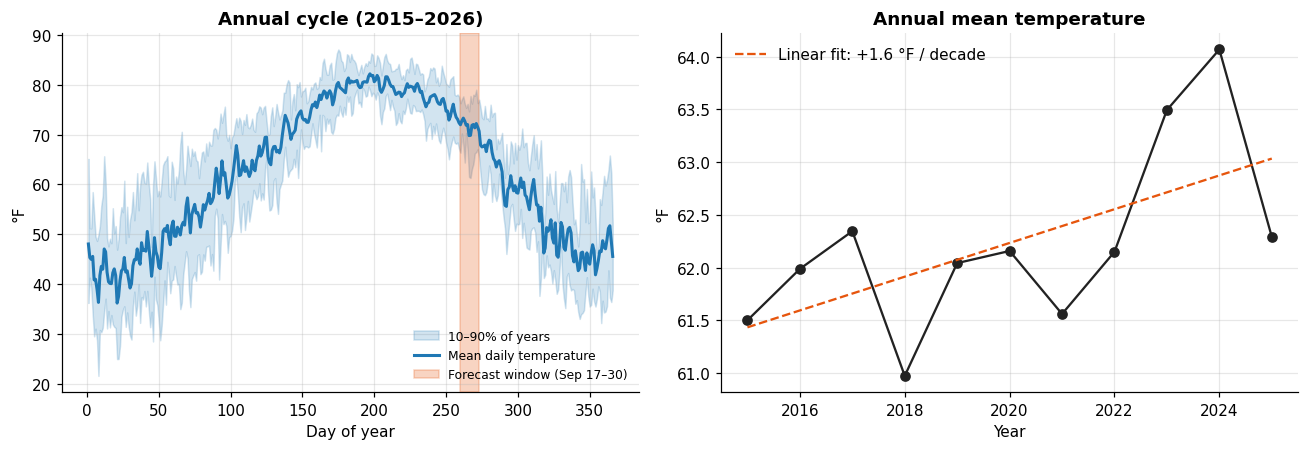

In [4]:
# Daily means and their 10-90% range for each day of the year
daily = obs.set_index("ds").y.resample("D").mean().dropna().to_frame("y")
daily["doy"] = daily.index.dayofyear
clim_doy = daily.groupby("doy").y.agg(["mean", lambda s: s.quantile(0.1), lambda s: s.quantile(0.9)])
clim_doy.columns = ["mean", "q10", "q90"]
# Yearly means and a linear fit to see the trend
yearly = obs[obs.ds.dt.year < 2026].groupby(obs.ds.dt.year).y.mean()
slope, intercept = np.polyfit(yearly.index, yearly.values, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].fill_between(clim_doy.index, clim_doy.q10, clim_doy.q90, color=COL["clim"], alpha=0.2, label="10–90% of years")
axes[0].plot(clim_doy.index, clim_doy["mean"], color=COL["clim"], lw=2, label="Mean daily temperature")
axes[0].axvspan(260, 273, color=COL["final"], alpha=0.25, label="Forecast window (Sep 17–30)")
axes[0].set(title="Annual cycle (2015–2026)", xlabel="Day of year", ylabel="°F"); axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(yearly.index, yearly.values, "o-", color=COL["actual"])
axes[1].plot(yearly.index, slope*yearly.index + intercept, "--", color=COL["final"], label=f"Linear fit: {10*slope:+.1f} °F / decade")
axes[1].set(title="Annual mean temperature", xlabel="Year", ylabel="°F"); axes[1].legend(frameon=False)
fig.tight_layout(); save(fig, "02_eda_annual_trend"); plt.show()

### 1.3 Autocorrelation of the anomaly
The anomaly is the real temperature minus the climatology. Its autocorrelation tells us how long a warm or cold period lasts: about 0.6 after 1 day, 0.3 after 2 days and almost 0 after 10 days.

So the current anomaly helps in the first days, but its effect has to fade with the horizon. We model this with features like anomaly × exp(−h/τ).

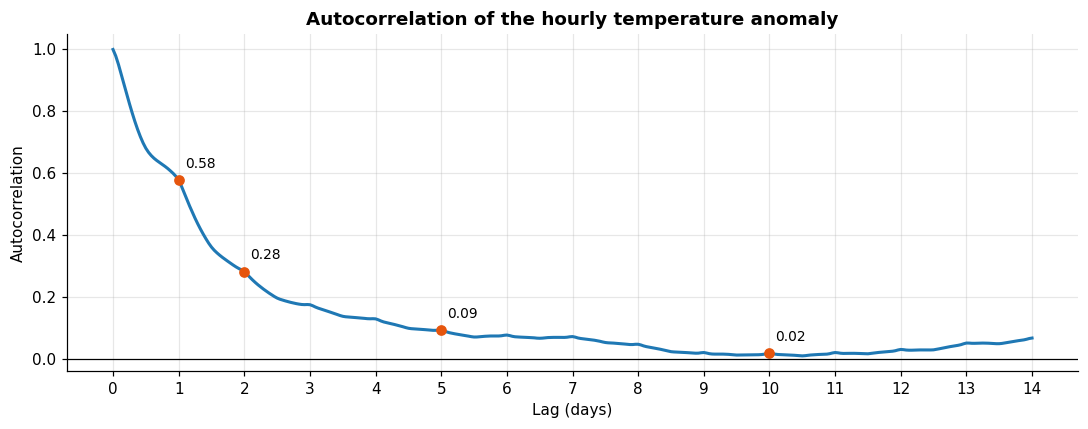

Anomaly std: 8.62 °F


In [5]:
# First we fit a calendar-only model and compute the anomaly
clim_model = LinearTemperatureForecaster(LRConfig(anomaly="none")).fit(history)
anom = history.set_index("ds").y - clim_model.climatology(history.ds)
# Then the autocorrelation for lags up to 14 days
lags_h = np.arange(0, HORIZON + 1)
acf = np.array([anom.autocorr(int(l)) if l else 1.0 for l in lags_h])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags_h / 24, acf, color=COL["clim"], lw=2)
for d in (1, 2, 5, 10):
    ax.annotate(f"{acf[24*d]:.2f}", (d, acf[24*d]), textcoords="offset points", xytext=(4, 8), fontsize=9)
    ax.plot(d, acf[24*d], "o", color=COL["final"])
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Autocorrelation of the hourly temperature anomaly", xlabel="Lag (days)", ylabel="Autocorrelation",
       xticks=range(0, 15))
fig.tight_layout(); save(fig, "03_eda_anomaly_acf"); plt.show()
print(f"Anomaly std: {anom.std():.2f} °F")

## 2. Evaluation design
- This is a time series, so we never split randomly. Every model is trained only with data before the period it predicts.
- To choose models and hyperparameters we use **time series cross-validation**: for each year 2017–2025 we train with data before Sep 1 and forecast four 14-day windows (Sep 3, 10, 17 and 24). That gives **36 windows** in the same season as the real forecast.
- We don't choose with a single window because it is too noisy (the MAE changes about 1.3 °F from one window to another).
- The test set (Sep 3–16 2026) is only used at the end to report results, like the rest of the team.
- Main metric: **MAE (°F)**.

## 3. Baselines
First we check simple references: repeating the last day, the month-hour average and a linear regression with the 4 shared features.

In [6]:
# We keep all the CV results to reuse them later
cv_results = {}
def run_cv(name, make):
    cv_results[name] = cross_validate(make, history)
    return {"model": name, **summarize_cv(cv_results[name])}

rows = [run_cv("Naive: repeat last day", NaiveLastDay),
        run_cv("Climatology: month-hour mean", MonthHourMean),
        run_cv("LR: 4 shared features", SharedFeaturesLR)]
pd.DataFrame(rows)[["model", "mae", "mae_window_std", "rmse", "bias"]].round(3)

,model,mae,mae_window_std,rmse,bias
0,Naive: repeat last day,6.170,1.569,7.784,-0.441
1,Climatology: month-hour mean,5.449,1.645,6.896,0.158
2,LR: 4 shared features,5.502,1.275,6.715,-1.478


## 4. Stage 1: climatology
Here we only use calendar features. We change one setting at a time and compare the training error with the CV error, and we pick the point where the CV error stops improving.

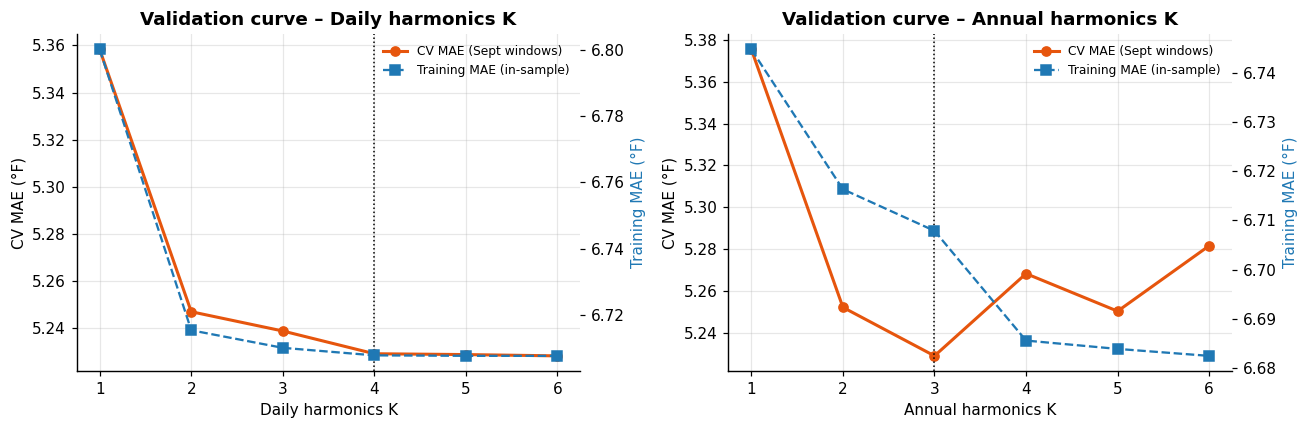

k_daily         k_annual       
  train_mae cv_mae train_mae cv_mae
1     6.800  5.358     6.745  5.375
2     6.715  5.247     6.716  5.252
3     6.710  5.239     6.708  5.229
4     6.708  5.229     6.686  5.268
5     6.708  5.229     6.684  5.250
6     6.708  5.228     6.682  5.282

In [7]:
stage1_base = LRConfig(k_daily=4, k_annual=3, k_interact=1, trend=True, anomaly="none")

# Training MAE (in-sample) and CV MAE for one configuration
def stage1_scores(cfg):
    train_mae = np.mean([LinearTemperatureForecaster(cfg).fit(history[history.ds < cut]).train_mae_stage1
                         for cut, _ in cv_folds()])
    cv_mae = summarize_cv(cross_validate(lambda: LinearTemperatureForecaster(cfg), history))["mae"]
    return train_mae, cv_mae

# Validation curves: we change one parameter at a time
vc = {}
for param, values in [("k_daily", range(1, 7)), ("k_annual", range(1, 7))]:
    vc[param] = pd.DataFrame([(v, *stage1_scores(replace(stage1_base, **{param: v}))) for v in values],
                             columns=[param, "train_mae", "cv_mae"]).set_index(param)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (param, label, chosen) in zip(axes, [("k_daily", "Daily harmonics K", 4), ("k_annual", "Annual harmonics K", 3)]):
    d = vc[param]
    ax.plot(d.index, d.cv_mae, "o-", color=COL["final"], lw=2, label="CV MAE (Sept windows)")
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(d.index, d.train_mae, "s--", color=COL["clim"], label="Training MAE (in-sample)")
    ax.axvline(chosen, color="k", ls=":", lw=1)
    ax.set(title=f"Validation curve – {label}", xlabel=label, ylabel="CV MAE (°F)")
    ax2.set_ylabel("Training MAE (°F)", color=COL["clim"])
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="upper right")
fig.tight_layout(); save(fig, "04_validation_curves"); plt.show()
pd.concat(vc, axis=1).round(3)

In [8]:
# Same idea for the interaction terms and the trend
other = []
for k in range(0, 4):
    other.append({"setting": f"k_interact={k}", **dict(zip(["train_mae", "cv_mae"], stage1_scores(replace(stage1_base, k_interact=k))))})
for t in (False, True):
    other.append({"setting": f"trend={t}", **dict(zip(["train_mae", "cv_mae"], stage1_scores(replace(stage1_base, trend=t))))})
pd.DataFrame(other).round(3)

,setting,train_mae,cv_mae
0,k_interact=0,6.733,5.237
1,k_interact=1,6.708,5.229
2,k_interact=2,6.703,5.229
3,k_interact=3,6.700,5.230
4,trend=False,6.711,5.224
5,trend=True,6.708,5.229


**Stage 1 choices:** 4 daily harmonics and 3 annual harmonics (with more, the training error goes down but the CV error goes up, so it overfits). One interaction order is enough. The trend doesn't change much here, but we keep it because it helps once we add stage 2 (section 5).

## 5. Stage 2: anomaly
Stage 2 is a regression on the residuals of stage 1. At the forecast start we compute the recent anomaly (last hour, 1, 3 and 7 days) and multiply it by exp(−h/τ), with τ = 6, 24, 72 and 168 hours.

To train it we simulate past forecasts, so the features are computed the same way as in the real forecast.
- *simple*: 1-day anomaly × 3 decays (3 features)
- *rich*: 4 anomalies × 4 decays (16 features)

In [9]:
stage_cfg = LRConfig(k_daily=4, k_annual=3, k_interact=1, trend=True)
# We add the parts one by one to see how much each one helps
ablation = [
    ("LR: calendar (stage 1 only)",         replace(stage_cfg, anomaly="none")),
    ("+ anomaly, simple (3 feats, OLS)",    replace(stage_cfg, anomaly="simple")),
    ("+ anomaly, rich (16 feats, OLS)",     replace(stage_cfg, anomaly="rich")),
    ("+ rich, no trend (OLS)",              replace(stage_cfg, anomaly="rich", trend=False)),
    ("+ rich, seasonal origins only (±60 d)", replace(stage_cfg, anomaly="rich", season_window_days=60)),
    ("Final: rich + Lasso (α=0.01)",        FINAL_CONFIG),
]
for name, cfg in ablation:
    rows.append(run_cv(name, lambda cfg=cfg: LinearTemperatureForecaster(cfg)))
cv_table = pd.DataFrame(rows)
cv_table[["model", "mae", "mae_window_std", "rmse", "bias"]].round(3)

,model,mae,mae_window_std,rmse,bias
0,Naive: repeat last day,6.170,1.569,7.784,-0.441
1,Climatology: month-hour mean,5.449,1.645,6.896,0.158
2,LR: 4 shared features,5.502,1.275,6.715,-1.478
3,LR: calendar (stage 1 only),5.229,1.370,6.495,0.118
4,"+ anomaly, simple (3 feats, OLS)",5.009,1.285,6.226,-0.246
5,"+ anomaly, rich (16 feats, OLS)",4.941,1.338,6.189,-0.182
6,"+ rich, no trend (OLS)",4.968,1.253,6.176,-0.680
7,"+ rich, seasonal origins only (±60 d)",5.001,1.312,6.245,-0.194
8,Final: rich + Lasso (α=0.01),4.932,1.331,6.176,-0.178


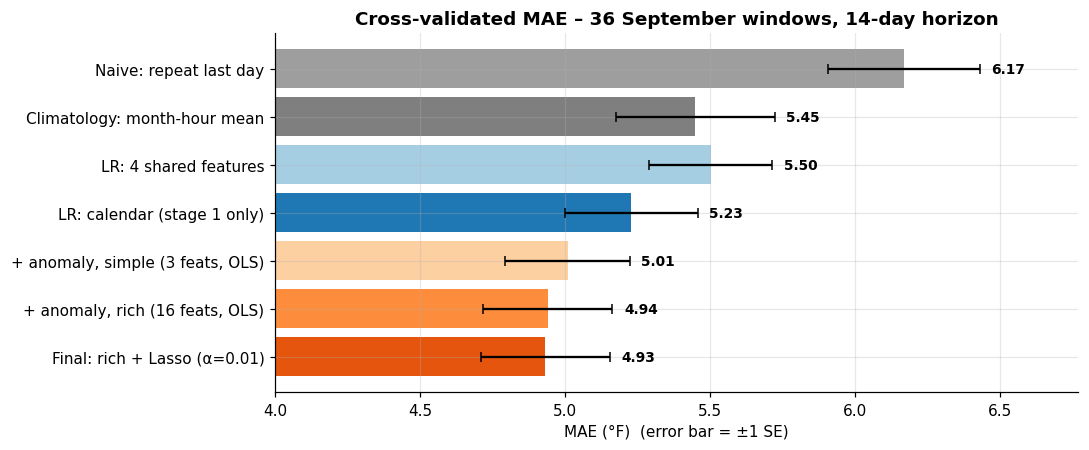

Final vs calendar-only: better in 30/36 windows, mean MAE reduction 0.30 ± 0.06 °F (±1 SE, paired)


In [10]:
# Bar chart with the CV MAE of every model
order = ["Naive: repeat last day", "Climatology: month-hour mean", "LR: 4 shared features",
         "LR: calendar (stage 1 only)", "+ anomaly, simple (3 feats, OLS)", "+ anomaly, rich (16 feats, OLS)",
         "Final: rich + Lasso (α=0.01)"]
d = cv_table.set_index("model").loc[order]
se = d.mae_window_std / np.sqrt(d.n_windows)
colors = [COL["naive"], COL["monthhour"], COL["shared"], COL["clim"], "#fdd0a2", "#fd8d3c", COL["final"]]
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(range(len(d)), d.mae, xerr=se, color=colors, capsize=3)
for i, (v, e) in enumerate(zip(d.mae, se)):
    ax.text(v + e + 0.04, i, f"{v:.2f}", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index); ax.invert_yaxis()
ax.set(title="Cross-validated MAE – 36 September windows, 14-day horizon", xlabel="MAE (°F)  (error bar = ±1 SE)",
       xlim=(4, d.mae.max() + 0.6))
fig.tight_layout(); save(fig, "05_ablation_cv_mae"); plt.show()

# Paired comparison: same 36 windows, final vs calendar-only
win = lambda cv: cv.dropna().groupby("origin").error.apply(lambda e: e.abs().mean())
diff = win(cv_results["LR: calendar (stage 1 only)"]) - win(cv_results["Final: rich + Lasso (α=0.01)"])
print(f"Final vs calendar-only: better in {(diff > 0).sum()}/{len(diff)} windows, "
      f"mean MAE reduction {diff.mean():.2f} ± {diff.std()/np.sqrt(len(diff)):.2f} °F (±1 SE, paired)")

Adding the anomaly gives the biggest improvement. The error bars overlap because some windows are harder for all the models, so the fair test is the paired comparison on the same windows (printed above). Training stage 2 only with September data is worse (less data, more variance).

## 6. Collinearity and regularization
The 16 anomaly features are very correlated (it's the same anomaly with different windows and decays). This makes the OLS coefficients unstable, so we try Ridge and Lasso and choose α with the same CV.

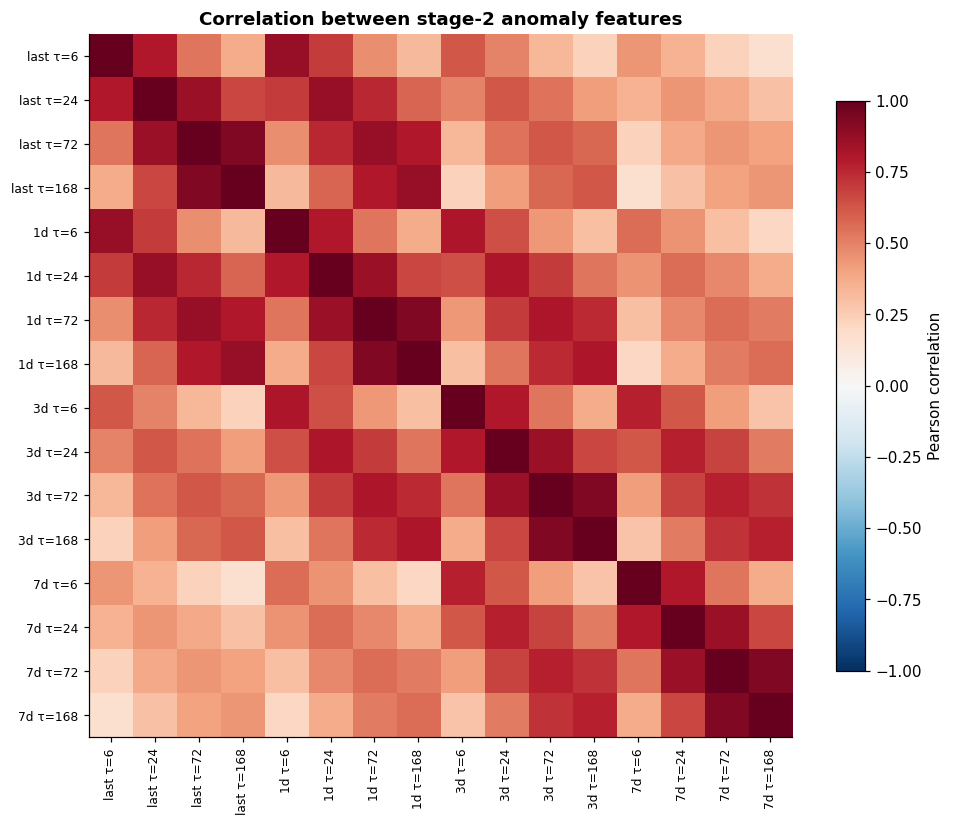

Pairs with |corr| > 0.9: 4 of 256


In [11]:
# Final model trained on all the history
final_full = LinearTemperatureForecaster(FINAL_CONFIG).fit(history, target_doy=FINAL_ORIGIN.dayofyear)
X_full, y_full = final_full.stage2_training_set(history)
# Correlation between the 16 anomaly features
corr = X_full.corr()
short = [c.replace("anom_", "").replace("_x_exp_h/", " τ=") for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=90, fontsize=8)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=8)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation between stage-2 anomaly features")
fig.tight_layout(); save(fig, "06_anomaly_feature_correlation"); plt.show()
upper = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
print(f"Pairs with |corr| > 0.9: {(upper.abs() > 0.9).sum()} of {len(upper)}")

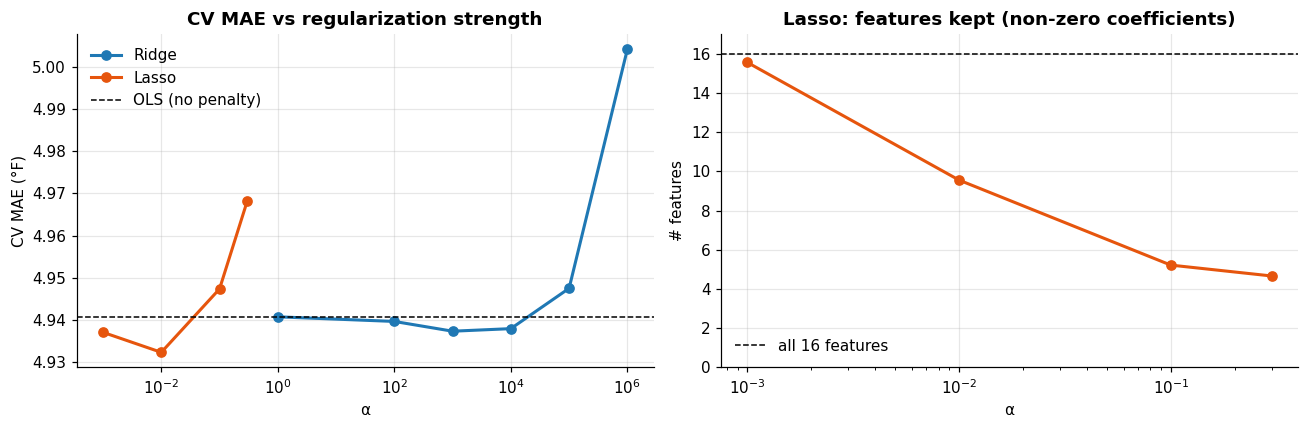

ridge α=1         4.9407
ridge α=100       4.9396
ridge α=1000      4.9373
ridge α=10000     4.9379
ridge α=100000    4.9474
ridge α=1e+06     5.0043
lasso α=0.001     4.9370
lasso α=0.01      4.9322
lasso α=0.1       4.9473
lasso α=0.3       4.9683
ols α=0           4.9407
Name: cv_mae, dtype: float64

In [12]:
# For each fold we build the stage 2 data once and then try all the alphas
alphas = {"ridge": [1, 1e2, 1e3, 1e4, 1e5, 1e6], "lasso": [1e-3, 1e-2, 1e-1, 3e-1]}
y_all = history.set_index("ds").y
abs_err = {(r, a): [] for r in alphas for a in alphas[r]}; abs_err[("ols", 0)] = []
nonzero = {a: [] for a in alphas["lasso"]}
for cutoff, origins in cv_folds():
    m = LinearTemperatureForecaster(replace(FINAL_CONFIG, regularization="none"))
    hist = history[history.ds < cutoff]; m._fit_stage1(hist)
    X, y = m.stage2_training_set(hist)
    windows = []
    for o in origins:
        ds = pd.date_range(o, periods=HORIZON, freq="h")
        st, t_st = state_at(anomaly_states(history[history.ds < o], m.climatology), o)
        windows.append((m.climatology(ds), anomaly_features(ds, st, t_st, "rich"), y_all.reindex(ds).values))
    for (r, a) in abs_err:
        cfg = replace(FINAL_CONFIG, regularization="none" if r == "ols" else r, alpha=a)
        model = LinearTemperatureForecaster(cfg)._make_stage2().fit(X, y)
        if r == "lasso":
            nonzero[a].append(int((model.named_steps["model"].coef_ != 0).sum()))
        abs_err[(r, a)] += [np.abs(c + model.predict(F) - t) for c, F, t in windows]
# Mean CV error for each alpha
reg_mae = {k: np.nanmean(np.concatenate(v)) for k, v in abs_err.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for r, c in (("ridge", COL["clim"]), ("lasso", COL["final"])):
    axes[0].plot(alphas[r], [reg_mae[(r, a)] for a in alphas[r]], "o-", color=c, lw=2, label=r.capitalize())
axes[0].axhline(reg_mae[("ols", 0)], color="k", ls="--", lw=1, label="OLS (no penalty)")
axes[0].set(xscale="log", title="CV MAE vs regularization strength", xlabel="α", ylabel="CV MAE (°F)")
axes[0].legend(frameon=False)
axes[1].plot(alphas["lasso"], [np.mean(nonzero[a]) for a in alphas["lasso"]], "o-", color=COL["final"], lw=2)
axes[1].axhline(16, color="k", ls="--", lw=1, label="all 16 features")
axes[1].set(xscale="log", title="Lasso: features kept (non-zero coefficients)", xlabel="α", ylabel="# features",
            ylim=(0, 17)); axes[1].legend(frameon=False)
fig.tight_layout(); save(fig, "07_regularization_path"); plt.show()
pd.Series({f"{r} α={a:g}": v for (r, a), v in reg_mae.items()}, name="cv_mae").round(4)

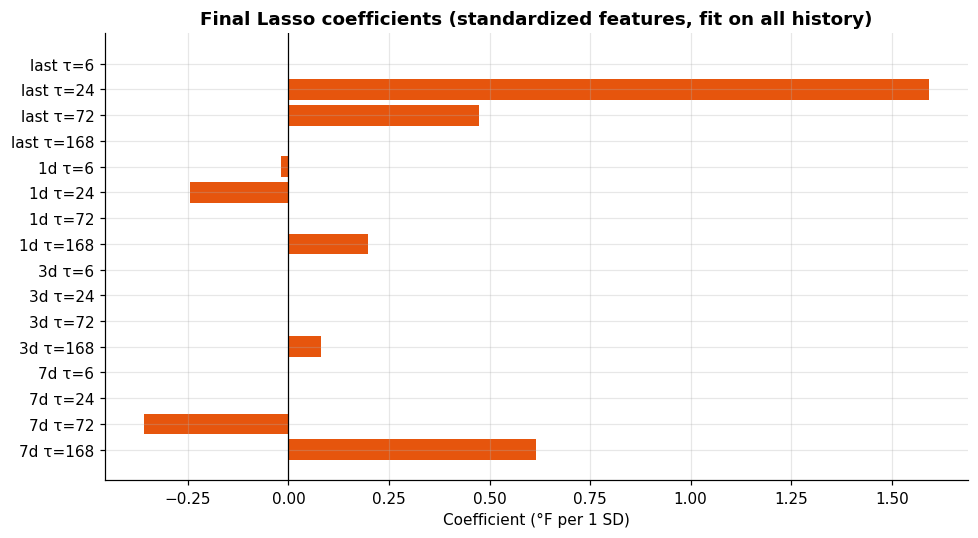

Non-zero: 8 of 16 -> dropped: ['last τ=6', 'last τ=168', '1d τ=72', '3d τ=6', '3d τ=24', '3d τ=72', '7d τ=6', '7d τ=24']


In [13]:
# Coefficients of the final Lasso (0 means the feature was dropped)
coef = pd.Series(final_full.stage2.named_steps["model"].coef_, index=short)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef.index, coef.values, color=np.where(coef.values == 0, "#cccccc", COL["final"]))
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis()
ax.set(title="Final Lasso coefficients (standardized features, fit on all history)", xlabel="Coefficient (°F per 1 SD)")
fig.tight_layout(); save(fig, "08_lasso_coefficients"); plt.show()
print(f"Non-zero: {(coef != 0).sum()} of {len(coef)} -> dropped: {list(coef.index[coef == 0])}")

The coefficients have mixed signs because the features are correlated and partly cancel each other, so we don't read them one by one. In section 7 we look at their combined effect.

**Regularization choice:** with ~600k rows and 16 features the variance is already low, so Ridge barely changes anything. **Lasso with α = 0.01** gets the best CV error and drops several redundant features, so it's simpler. This is our final model.

## 7. Interpretation
We check what the model learned: how much of a +1 °F anomaly is still there after h hours, compared with the real autocorrelation of the data.

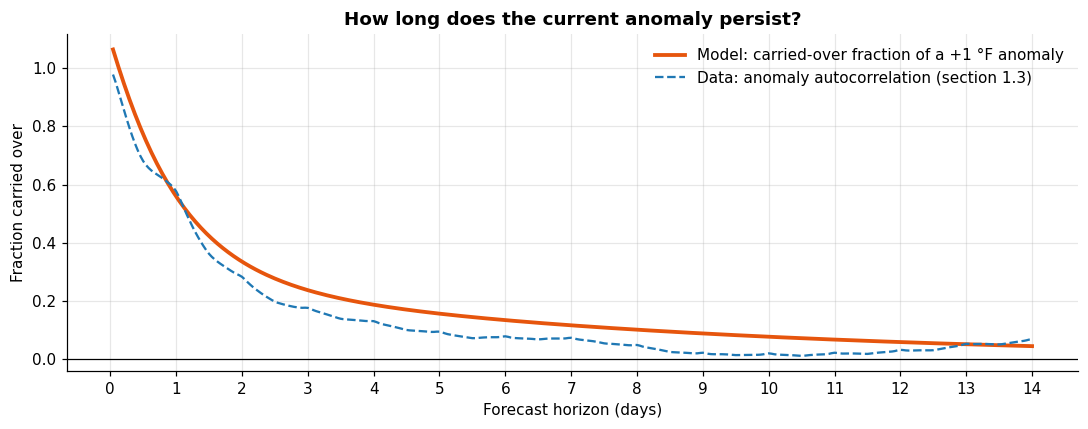

Carried-over fraction after 1 day: 0.56, 3 days: 0.24, 7 days: 0.11, 14 days: 0.04
Stage-1 trend coefficient: +1.64 °F per decade


In [14]:
# Response of the forecast to a sustained +1 °F anomaly (all summaries = +1) vs. horizon
t0 = FINAL_ORIGIN - pd.Timedelta(hours=1)
ds = pd.date_range(FINAL_ORIGIN, periods=HORIZON, freq="h")
one = {k: 1.0 for k in ANOMALY_SUMMARIES}; zero = {k: 0.0 for k in ANOMALY_SUMMARIES}
response = (final_full.stage2.predict(anomaly_features(ds, one, t0, "rich"))
            - final_full.stage2.predict(anomaly_features(ds, zero, t0, "rich")))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, HORIZON + 1) / 24, response, color=COL["final"], lw=2.5, label="Model: carried-over fraction of a +1 °F anomaly")
ax.plot(lags_h[1:] / 24, acf[1:], color=COL["clim"], lw=1.5, ls="--", label="Data: anomaly autocorrelation (section 1.3)")
ax.axhline(0, color="k", lw=0.8)
ax.set(title="How long does the current anomaly persist?", xlabel="Forecast horizon (days)", ylabel="Fraction carried over",
       xticks=range(0, 15)); ax.legend(frameon=False)
fig.tight_layout(); save(fig, "09_persistence_curve"); plt.show()

# Trend coefficient from stage 1
trend_coef = pd.Series(final_full.stage1.coef_, index=final_full._cal(ds[:1]).columns)["trend_years"]
print(f"Carried-over fraction after 1 day: {response[23]:.2f}, 3 days: {response[71]:.2f}, 7 days: {response[167]:.2f}, 14 days: {response[-1]:.2f}")
print(f"Stage-1 trend coefficient: {10*trend_coef:+.2f} °F per decade")

The model learned the same shape as the data: it keeps around half of the anomaly after one day and then it goes back to the climatology.

## 8. Residuals
We check the linear regression assumptions with the residuals of the final model on the 36 CV windows.

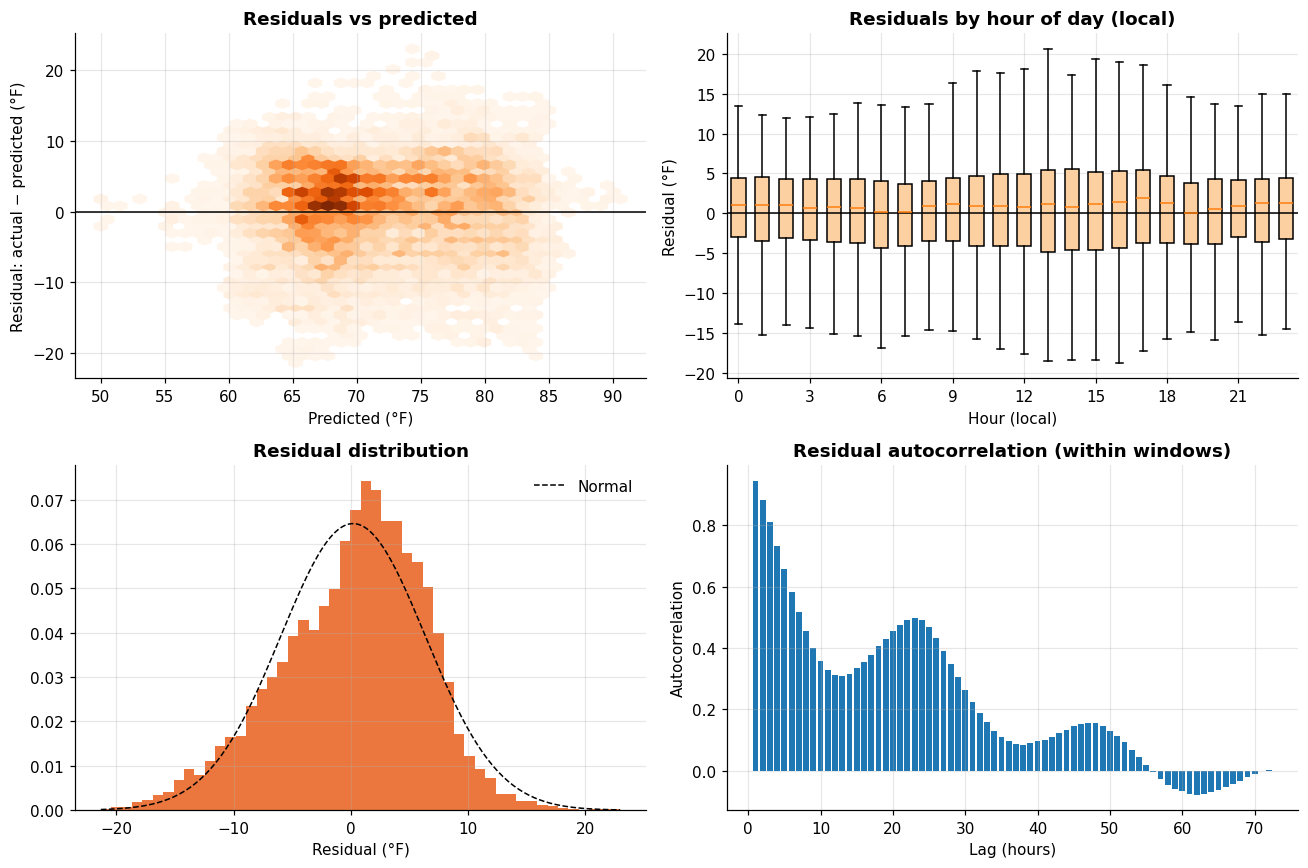

Residual mean +0.18 °F | std 6.17 °F | skew -0.39 | lag-24h autocorr 0.49
Residual std by local hour: {0: 5.7, 1: 5.8, 2: 5.8, 3: 6.0, 4: 6.1, 5: 6.3, 6: 6.4, 7: 5.9, 8: 5.4, 9: 5.6, 10: 6.0, 11: 6.4, 12: 6.8, 13: 7.0, 14: 6.9, 15: 6.9, 16: 6.8, 17: 6.5, 18: 6.1, 19: 5.8, 20: 5.8, 21: 5.8, 22: 5.8, 23: 6.0}


In [15]:
# Residuals = real - predicted, on the CV windows
res = cv_results["Final: rich + Lasso (α=0.01)"].dropna().copy()
res["resid"] = res.y - res.yhat
res["local_hour"] = res.ds.dt.tz_convert(LOCAL_TZ).dt.hour

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
hb = axes[0, 0].hexbin(res.yhat, res.resid, gridsize=40, cmap="Oranges", mincnt=1)
axes[0, 0].axhline(0, color="k", lw=1)
axes[0, 0].set(title="Residuals vs predicted", xlabel="Predicted (°F)", ylabel="Residual: actual − predicted (°F)")
axes[0, 1].boxplot([res.loc[res.local_hour == h, "resid"] for h in range(24)], positions=range(24), widths=0.6,
                   showfliers=False, patch_artist=True, boxprops=dict(facecolor="#fdd0a2"))
axes[0, 1].axhline(0, color="k", lw=1)
axes[0, 1].set(title="Residuals by hour of day (local)", xlabel="Hour (local)", ylabel="Residual (°F)")
axes[0, 1].set_xticks(range(0, 24, 3)); axes[0, 1].set_xticklabels(range(0, 24, 3))
axes[1, 0].hist(res.resid, bins=50, color=COL["final"], alpha=0.8, density=True)
xs = np.linspace(res.resid.min(), res.resid.max(), 200)
axes[1, 0].plot(xs, np.exp(-0.5*((xs-res.resid.mean())/res.resid.std())**2)/(res.resid.std()*np.sqrt(2*np.pi)), "k--", lw=1, label="Normal")
axes[1, 0].set(title="Residual distribution", xlabel="Residual (°F)"); axes[1, 0].legend(frameon=False)
# Autocorrelation of the residuals inside each window
racf = [np.nanmean([w.resid.autocorr(l) for _, w in res.groupby("origin")]) for l in range(1, 73)]
axes[1, 1].bar(np.arange(1, 73), racf, color=COL["clim"])
axes[1, 1].set(title="Residual autocorrelation (within windows)", xlabel="Lag (hours)", ylabel="Autocorrelation")
fig.tight_layout(); save(fig, "10_residual_diagnostics"); plt.show()
print(f"Residual mean {res.resid.mean():+.2f} °F | std {res.resid.std():.2f} °F | skew {res.resid.skew():.2f} | lag-24h autocorr {racf[23]:.2f}")
print("Residual std by local hour:", res.groupby("local_hour").resid.std().round(1).to_dict())

- **Mean ≈ 0** and no clear pattern against the predictions, so there is no big bias left.
- **By hour:** the errors are bigger in the afternoon (std ≈ 7 °F at 12–16 h vs ≈ 5.5–6 °F at night). The daily maximum depends on clouds and rain, which we can't know 14 days before.
- **Distribution:** a bit skewed to the left. The biggest errors are days much colder than expected (rain, fronts).
- **Errors are autocorrelated:** a weather situation the model doesn't see lasts several days. The predictions are still fine, but normal confidence intervals would be too narrow. That's why in section 11 we build the band with the real CV errors.

## 9. Error by forecast day

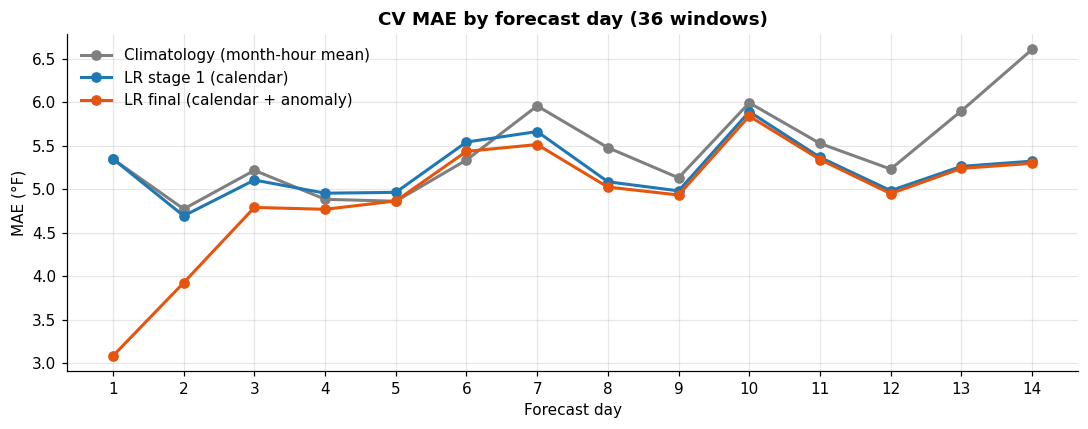

In [16]:
def mae_by_day(cv):
    d = cv.dropna(); return d.assign(day=(d.horizon_h - 1)//24 + 1).groupby("day").error.apply(lambda e: e.abs().mean())

# MAE for each forecast day (1 to 14)
fig, ax = plt.subplots(figsize=(10, 4))
for name, c, lab in [("Climatology: month-hour mean", COL["monthhour"], "Climatology (month-hour mean)"),
                     ("LR: calendar (stage 1 only)", COL["clim"], "LR stage 1 (calendar)"),
                     ("Final: rich + Lasso (α=0.01)", COL["final"], "LR final (calendar + anomaly)")]:
    s = mae_by_day(cv_results[name]); ax.plot(s.index, s.values, "o-", color=c, lw=2, label=lab)
ax.set(title="CV MAE by forecast day (36 windows)", xlabel="Forecast day", ylabel="MAE (°F)", xticks=range(1, 15))
ax.legend(frameon=False)
fig.tight_layout(); save(fig, "11_mae_by_forecast_day"); plt.show()

The anomaly helps mostly in **days 1–3**. After about one week the model is basically the climatology, as we expected from the autocorrelation.

## 10. Validation and test
Same protocol as the rest of the team: train on train and score val, then train on train + val and score test. We don't make any decision here, it's only to report results.

In [17]:
# Same protocol as prophet_model.py
models = {"Naive: repeat last day": NaiveLastDay, "Climatology: month-hour mean": MonthHourMean,
          "LR: 4 shared features": SharedFeaturesLR,
          "LR: calendar (stage 1 only)": lambda: LinearTemperatureForecaster(replace(FINAL_CONFIG, anomaly="none")),
          "LR final": lambda: LinearTemperatureForecaster(FINAL_CONFIG)}
train_val = pd.concat([train, val], ignore_index=True)
rows_vt, test_pred = [], test[["ds", "y"]].copy()
for split, fit_df, ev in (("val", train, val), ("test", train_val, test)):
    scale = make_mase_scale(fit_df)
    for name, make in models.items():
        p = make().fit(fit_df, target_doy=ev.ds.iloc[0].dayofyear).predict(fit_df, ev.ds)
        rows_vt.append({"split": split, "model": name, **calculate_metrics(ev.y, p, scale)})
        if split == "test": test_pred[name] = p
vt = pd.DataFrame(rows_vt)
# If Yan's Prophet predictions are there, we add them to compare
prophet_path = ROOT / "outputs" / "predictions" / "prophet_test_predictions.csv"
if prophet_path.is_file():
    pr = pd.read_csv(prophet_path); pr["ds"] = pd.to_datetime(pr.ds, utc=True)
    test_pred = test_pred.merge(pr[["ds", "yhat"]].rename(columns={"yhat": "Prophet"}), on="ds", how="left")
    vt = pd.concat([vt, pd.DataFrame([{"split": "test", "model": "Prophet (Yan)",
                                       **calculate_metrics(test_pred.y, test_pred.Prophet, make_mase_scale(train_val))}])])
vt.pivot(index="model", columns="split", values="mae").round(3)

split,test,val
model,,
Climatology: month-hour mean,6.332,4.771
LR final,4.231,4.226
LR: 4 shared features,6.320,4.462
LR: calendar (stage 1 only),5.032,4.200
Naive: repeat last day,8.107,5.426
Prophet (Yan),5.446,NaN


In [18]:
vt[["split", "model", "mae", "rmse", "mase", "r2", "bias"]].round(3)

,split,model,mae,rmse,mase,r2,bias
0,val,Naive: repeat last day,5.426,6.496,0.926,0.275,4.009
1,val,Climatology: month-hour mean,4.771,6.414,0.814,0.293,-1.167
2,val,LR: 4 shared features,4.462,5.828,0.761,0.417,-2.250
3,val,LR: calendar (stage 1 only),4.200,5.341,0.717,0.510,-0.477
4,val,LR final,4.226,5.405,0.721,0.498,0.095
5,test,Naive: repeat last day,8.107,9.655,1.385,-0.418,8.018
6,test,Climatology: month-hour mean,6.332,7.698,1.082,0.099,-5.771
7,test,LR: 4 shared features,6.320,7.656,1.079,0.108,-5.715
8,test,LR: calendar (stage 1 only),5.032,6.152,0.859,0.424,-3.867
9,test,LR final,4.231,5.177,0.723,0.592,-2.622


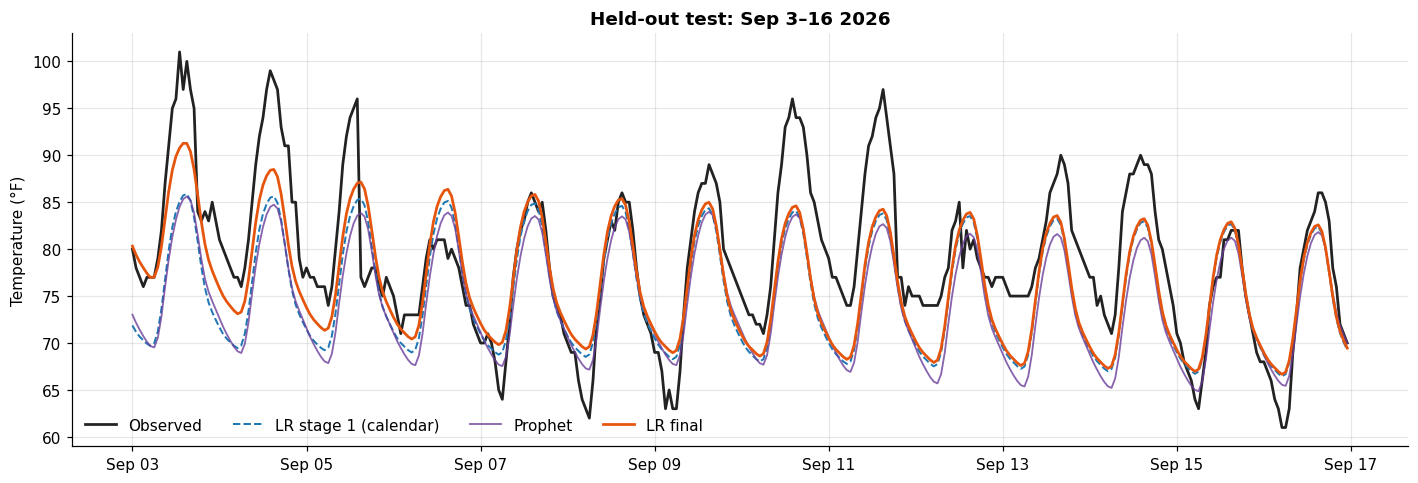

In [19]:
# Test period in local time
tp = test_pred.copy(); tp["local"] = tp.ds.dt.tz_convert(LOCAL_TZ)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(tp.local, tp.y, color=COL["actual"], lw=1.8, label="Observed")
ax.plot(tp.local, tp["LR: calendar (stage 1 only)"], color=COL["clim"], lw=1.3, ls="--", label="LR stage 1 (calendar)")
if "Prophet" in tp: ax.plot(tp.local, tp.Prophet, color=COL["prophet"], lw=1.2, alpha=0.8, label="Prophet")
ax.plot(tp.local, tp["LR final"], color=COL["final"], lw=1.8, label="LR final")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=tp.local.dt.tz))
ax.set(title="Held-out test: Sep 3–16 2026", ylabel="Temperature (°F)"); ax.legend(frameon=False, ncol=4, loc="lower left")
fig.tight_layout(); save(fig, "12_test_actual_vs_predicted"); plt.show()

The test period was very warm (about +6 °F above normal). The calendar-only models predict too low every day, and the anomaly stage fixes part of it. In the validation window the calendar-only model is a bit better, which shows again why we decide with the 36 CV windows and not with one window.

## 11. Final forecast (Sep 17 00:00 – Sep 30 23:00 EDT)
We train on all the history and forecast the 336 hours. The band is the 10–90% range of the CV errors for each forecast hour.

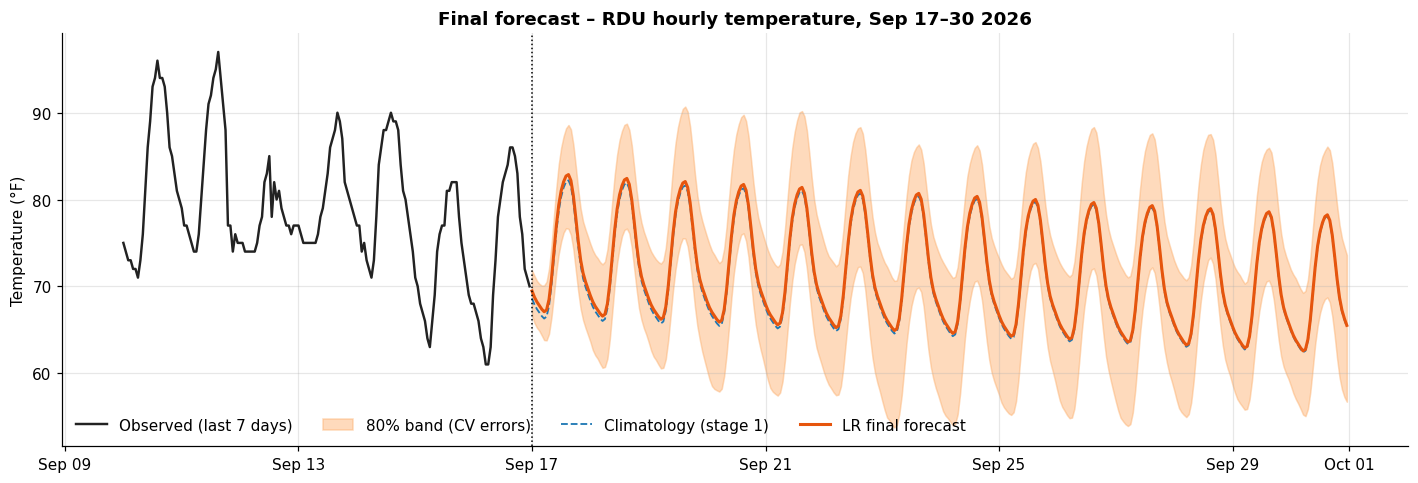

History ends 2026-09-17 03:00:00+00:00 UTC | mean forecast 71.6 °F | anomaly correction day 1: +0.71 °F, day 14: +0.15 °F


In [20]:
# Final forecast with the model trained on all the history
final_ds = pd.date_range(FINAL_ORIGIN, periods=HORIZON, freq="h")
yhat, clim, corr = final_full.predict(history, final_ds, return_parts=True)
# Band from the 10-90% quantiles of the CV errors at each hour
err = cv_results["Final: rich + Lasso (α=0.01)"].dropna()
q = err.groupby("horizon_h").error.quantile([0.1, 0.9]).unstack().rolling(12, center=True, min_periods=1).mean()
forecast = pd.DataFrame({"ds_utc": final_ds, "ds_local": final_ds.tz_convert(LOCAL_TZ), "yhat": yhat,
                         "lower_80": yhat - q[0.9].values, "upper_80": yhat - q[0.1].values,
                         "climatology": clim, "anomaly_correction": corr})
forecast.to_csv(ROOT / "outputs" / "predictions" / "linear_regression_final_forecast.csv", index=False)

# Plot the last 7 days and the forecast
recent = history[history.ds >= FINAL_ORIGIN - pd.Timedelta(days=7)].copy()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(recent.ds.dt.tz_convert(LOCAL_TZ), recent.y, color=COL["actual"], lw=1.6, label="Observed (last 7 days)")
ax.fill_between(forecast.ds_local, forecast.lower_80, forecast.upper_80, color=COL["band"], alpha=0.45, label="80% band (CV errors)")
ax.plot(forecast.ds_local, forecast.climatology, color=COL["clim"], lw=1.2, ls="--", label="Climatology (stage 1)")
ax.plot(forecast.ds_local, forecast.yhat, color=COL["final"], lw=2, label="LR final forecast")
ax.axvline(forecast.ds_local.iloc[0], color="k", lw=1, ls=":")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=forecast.ds_local.dt.tz))
ax.set(title="Final forecast – RDU hourly temperature, Sep 17–30 2026", ylabel="Temperature (°F)")
ax.legend(frameon=False, ncol=4, loc="lower left")
fig.tight_layout(); save(fig, "13_final_forecast"); plt.show()
print(f"History ends {history.ds.max()} UTC | mean forecast {yhat.mean():.1f} °F | "
      f"anomaly correction day 1: {corr[:24].mean():+.2f} °F, day 14: {corr[-24:].mean():+.2f} °F")

## 12. Summary

In [21]:
pd.DataFrame([
    ("Validation", "36-window time-series CV (Sep, 2017–2025)", "single 14-day windows are too noisy (MAE std ≈ 1.3 °F)"),
    ("Daily harmonics", "K = 4", "CV improves up to 4, flat afterwards"),
    ("Annual harmonics", "K = 3", "K ≥ 4: train error ↓ but CV error ↑ (overfitting)"),
    ("Interactions", "daily k=1 × annual", "season changes daily range/timing; more terms add nothing"),
    ("Trend", "linear, years since 2015", "warming in EDA; small CV gain in final model"),
    ("Anomaly features", "4 summaries × 4 decays", "largest gain; persistence matches anomaly ACF"),
    ("Regularization", "Lasso α = 0.01", "same/best CV MAE with fewer collinear features"),
    ("Stage-2 sampling", "all seasons", "season-only origins → fewer samples, worse CV"),
], columns=["Decision", "Choice", "Evidence"])

,Decision,Choice,Evidence
0,Validation,"36-window time-series CV (Sep, 2017–2025)",single 14-day windows are too noisy (MAE std ≈...
1,Daily harmonics,K = 4,"CV improves up to 4, flat afterwards"
2,Annual harmonics,K = 3,K ≥ 4: train error ↓ but CV error ↑ (overfitting)
3,Interactions,daily k=1 × annual,season changes daily range/timing; more terms ...
4,Trend,"linear, years since 2015",warming in EDA; small CV gain in final model
5,Anomaly features,4 summaries × 4 decays,largest gain; persistence matches anomaly ACF
6,Regularization,Lasso α = 0.01,same/best CV MAE with fewer collinear features
7,Stage-2 sampling,all seasons,"season-only origins → fewer samples, worse CV"
